<a href="https://colab.research.google.com/github/cdfloresc/Algoritmos-de-Enjambre/blob/main/Algoritmos_de_Enjambre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 03: Algoritmos de Enjambre
**Autor:** Cristian Darwin Flores Cueva

## Preparativos e Instalación
Instalamos las librerías necesarias y configuramos el entorno. Utilizaremos `pyswarms` para PSO y datasets de `scikit-learn`.

In [21]:
!pip install pyswarms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore')

## Reto A: Selección de Características (Feature Selection) con ABC
**Objetivo:** Utilizar el algoritmo de Colonia Artificial de Abejas (ABC) para encontrar el mejor subconjunto de características que maximice la precisión de un modelo de Árbol de Decisión, descartando variables ruidosas.
**Dataset:** Dataset sintético de clasificación (5,000 muestras, 100 características totales, donde solo 15 son realmente informativas).

**El Ciclo del Algoritmo (ABC Binario):**
1. **Representación:** Cada abeja representa una solución binaria (ej. `[1, 0, 1...]`) donde `1` incluye la característica y `0` la excluye. La longitud del vector es 100.
2. **Inicialización:** Generamos fuentes de alimento (vectores binarios) de manera aleatoria.
3. **Aptitud (Fitness):** Calculamos la precisión del modelo (DecisionTreeClassifier). La aptitud es $f(x) = \text{Accuracy} - \text{Penalización}$, donde se penaliza ligeramente usar demasiadas características.
4. **Comportamiento y Evolución:** - *Abejas empleadas:* Buscan en la vecindad de su fuente actual (voltean el valor de una característica al azar).
   - *Abejas observadoras:* Eligen las mejores fuentes para seguir explorando basadas en la aptitud compartida (usando probabilidad proporcional al fitness).
   - *Abejas exploradoras:* Si una fuente se estanca y no mejora tras varios intentos, se abandona y se busca una nueva al azar.

In [22]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X_a, y_a = make_classification(n_samples=5000, n_features=100, n_informative=15,
                               n_redundant=5, n_repeated=0, random_state=42)

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_a, y_a, test_size=0.3, random_state=42)
print(f"Dimensiones - Entrenamiento: {X_train_a.shape} | Prueba: {X_test_a.shape}")

Dimensiones - Entrenamiento: (3500, 100) | Prueba: (1500, 100)


In [23]:
n_bees = 30
n_features = X_a.shape[1]
max_iter = 40
limit = 10

population = np.random.randint(2, size=(n_bees, n_features))
trials = np.zeros(n_bees)
fitness = np.zeros(n_bees)

def evaluate_fitness_abc(solution):
    if np.sum(solution) == 0: return 0.0

    X_tr_sub = X_train_a[:, solution == 1]
    X_te_sub = X_test_a[:, solution == 1]

    clf = DecisionTreeClassifier(max_depth=5, random_state=42)
    clf.fit(X_tr_sub, y_train_a)
    acc = accuracy_score(y_test_a, clf.predict(X_te_sub))

    penalty = 0.001 * np.sum(solution)
    return acc - penalty

In [ ]:
for i in range(n_bees):
    fitness[i] = evaluate_fitness_abc(population[i])

best_solution = population[np.argmax(fitness)].copy()
best_fitness = np.max(fitness)
history_abc = []

for iteration in range(max_iter):
    # Empleadas
    for i in range(n_bees):
        new_solution = population[i].copy()
        idx = np.random.randint(n_features)
        new_solution[idx] = 1 - new_solution[idx]
        new_fit = evaluate_fitness_abc(new_solution)
        if new_fit > fitness[i]:
            population[i] = new_solution; fitness[i] = new_fit; trials[i] = 0
        else:
            trials[i] += 1

    # Observadoras
    prob = fitness / np.sum(fitness)
    for i in range(n_bees):
        selected_idx = np.random.choice(n_bees, p=prob)
        new_solution = population[selected_idx].copy()
        idx = np.random.randint(n_features)
        new_solution[idx] = 1 - new_solution[idx]
        new_fit = evaluate_fitness_abc(new_solution)
        if new_fit > fitness[selected_idx]:
            population[selected_idx] = new_solution; fitness[selected_idx] = new_fit; trials[selected_idx] = 0
        else:
            trials[selected_idx] += 1

    # Exploradoras
    for i in range(n_bees):
        if trials[i] > limit:
            population[i] = np.random.randint(2, size=(n_features,))
            fitness[i] = evaluate_fitness_abc(population[i])
            trials[i] = 0

    if np.max(fitness) > best_fitness:
        best_fitness = np.max(fitness)
        best_solution = population[np.argmax(fitness)].copy()
    history_abc.append(best_fitness)


Características seleccionadas: 42 de 100


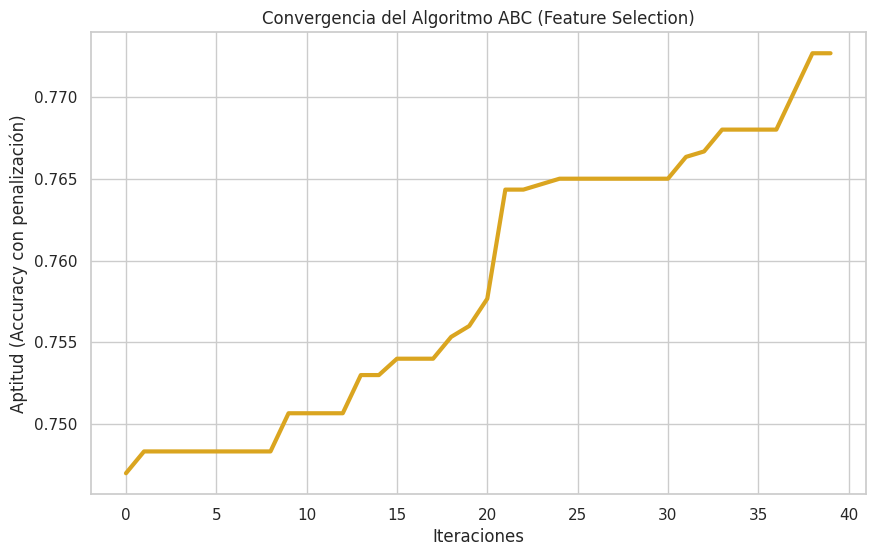

In [25]:
print(f"\nCaracterísticas seleccionadas: {np.sum(best_solution)} de {n_features}")

plt.plot(history_abc, lw=3, color='goldenrod')
plt.title('Convergencia del Algoritmo ABC (Feature Selection)')
plt.xlabel('Iteraciones')
plt.ylabel('Aptitud (Accuracy con penalización)')
plt.show()

## Reto B: Ajuste de Hiperparámetros (Hyperparameter Tuning) con PSO
**Objetivo:** Utilizar la Optimización por Enjambre de Partículas (PSO) para encontrar los mejores parámetros de un modelo Random Forest (`n_estimators`, `max_depth` y `min_samples_split`).
**Dataset:** Dataset sintético de clasificación masiva (10,000 muestras, 20 características).

**El Ciclo del Algoritmo (PSO):**
1. **Representación:** Una partícula es un vector de 3 dimensiones continuas mapeadas a enteros: `[n_estimators, max_depth, min_samples_split]`.
2. **Inicialización:** Las partículas se distribuyen aleatoriamente dentro de rangos predefinidos para cada hiperparámetro.
3. **Aptitud (Fitness):** Calculamos el rendimiento del modelo usando validación cruzada. Como PSO minimiza, la aptitud es $f(x) = 1 - \text{CrossValScore}$.
4. **Comportamiento y Evolución:** Las partículas actualizan su velocidad y posición hacia los mejores valores hiperparamétricos basándose en su mejor experiencia personal (`pBest`) y la mejor del enjambre (`gBest`).

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import pyswarms as ps

X_b, y_b = make_classification(n_samples=10000, n_features=20, random_state=100)
print(f"Dataset B dimensiones: {X_b.shape}")

def optimize_rf(swarm):
    n_particles = swarm.shape[0]
    scores = np.zeros(n_particles)

    for i in range(n_particles):
        n_est = int(swarm[i, 0])
        m_depth = int(swarm[i, 1])
        m_split = int(swarm[i, 2])

        if n_est < 10: n_est = 10
        if m_depth < 1: m_depth = 1
        if m_split < 2: m_split = 2

        rf = RandomForestClassifier(n_estimators=n_est, max_depth=m_depth,
                                    min_samples_split=m_split, n_jobs=-1, random_state=42)

        acc = cross_val_score(rf, X_b, y_b, cv=3).mean()
        scores[i] = 1 - acc

    return scores

Dataset B dimensiones: (10000, 20)


2026-05-02 02:48:42,722 - pyswarms.single.global_best - INFO - Optimize for 15 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.8}


Iniciando ajuste de hiperparámetros...


pyswarms.single.global_best: 100%|██████████|15/15, best_cost=0.0556
2026-05-02 03:08:59,146 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.05559998111388831, best pos: [87.9256486  22.65903786  7.68008092]



--- Resultados Óptimos ---
Estimadores (Árboles): 87
Profundidad Máxima: 22
Mínimo para dividir: 7
Accuracy alcanzado: 94.44%


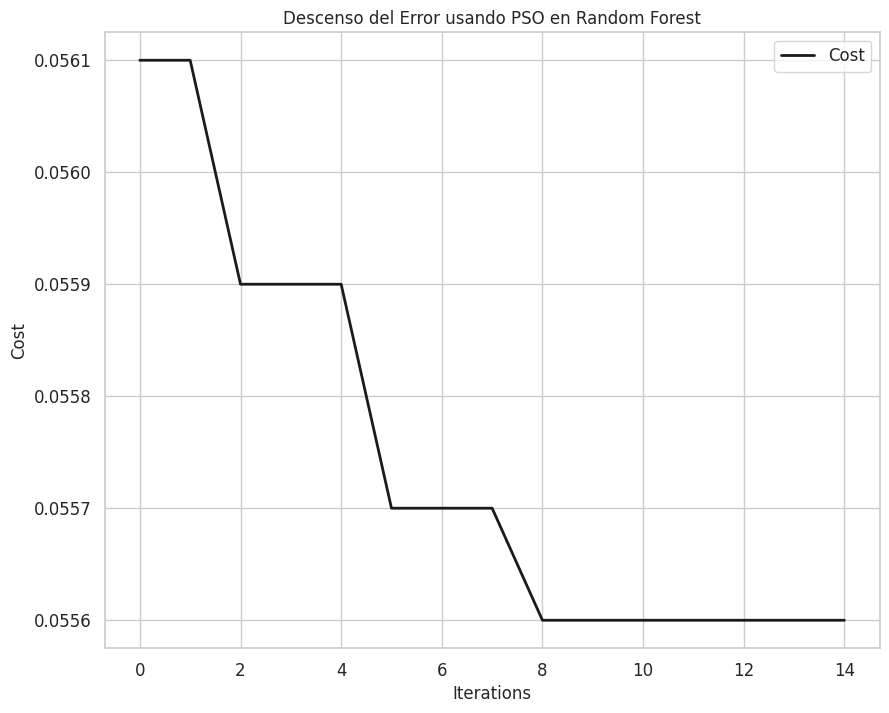

In [27]:
bounds = (np.array([10, 5, 2]), np.array([200, 30, 20]))
options = {'c1': 1.5, 'c2': 1.5, 'w': 0.8}
optimizer_rf = ps.single.GlobalBestPSO(n_particles=10, dimensions=3, options=options, bounds=bounds)

print("Iniciando ajuste de hiperparámetros...")
best_cost_rf, best_pos_rf = optimizer_rf.optimize(optimize_rf, iters=15)

print("\n--- Resultados Óptimos ---")
print(f"Estimadores (Árboles): {int(best_pos_rf[0])}")
print(f"Profundidad Máxima: {int(best_pos_rf[1])}")
print(f"Mínimo para dividir: {int(best_pos_rf[2])}")
print(f"Accuracy alcanzado: {(1 - best_cost_rf)*100:.2f}%")

from pyswarms.utils.plotters import plot_cost_history
plot_cost_history(cost_history=optimizer_rf.cost_history)
plt.title('Descenso del Error usando PSO en Random Forest')
plt.show()

## Reto C: Entrenamiento de Red Neuronal (Pesos y Bias) sin Backpropagation
**Objetivo:** Usar PSO para encontrar los pesos de una Red Neuronal Multicapa (MLP) diseñada para resolver un problema de clasificación no lineal complejo.
**Dataset:** Dataset `make_circles` (2,000 muestras concéntricas con ruido).

**El Ciclo del Algoritmo:**
1. **Representación:** Una partícula es un vector continuo que contiene TODOS los pesos y sesgos de la red. Una arquitectura de 2(entrada)->10(oculta)->2(salida) resulta en un vector de 42 dimensiones.
2. **Inicialización:** Posiciones aleatorias en el espacio de pesos.
3. **Aptitud (Fitness):** Minimizar la función de pérdida `Log Loss` (Entropía Cruzada) al hacer un *forward pass* con los datos de entrenamiento.
4. **Comportamiento y Evolución:** Las partículas "vuelan" multidimensionalmente guiadas por `pBest` y `gBest` hasta encontrar la combinación de pesos que genera el menor error de predicción.

In [28]:
from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss

X_c, y_c = make_circles(n_samples=2000, noise=0.1, factor=0.4, random_state=42)
X_c = StandardScaler().fit_transform(X_c)

y_one_hot_c = np.zeros((y_c.size, y_c.max() + 1))
y_one_hot_c[np.arange(y_c.size), y_c] = 1

n_in, n_hid, n_out = 2, 10, 2
dim_total = (n_in * n_hid) + n_hid + (n_hid * n_out) + n_out

def relu(z): return np.maximum(0, z)
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def forward_pass(params, X_data):
    W1_end = n_in * n_hid
    b1_end = W1_end + n_hid
    W2_end = b1_end + (n_hid * n_out)

    W1 = params[0:W1_end].reshape((n_in, n_hid))
    b1 = params[W1_end:b1_end].reshape((n_hid,))
    W2 = params[b1_end:W2_end].reshape((n_hid, n_out))
    b2 = params[W2_end:].reshape((n_out,))

    A1 = relu(np.dot(X_data, W1) + b1)
    return softmax(np.dot(A1, W2) + b2)

def evaluate_nn_pso(swarm):
    losses = np.zeros(swarm.shape[0])
    for i in range(swarm.shape[0]):
        preds = forward_pass(swarm[i], X_c)
        losses[i] = log_loss(y_one_hot_c, preds)
    return losses

2026-05-02 03:08:59,399 - pyswarms.single.global_best - INFO - Optimize for 150 iters with {'c1': 0.6, 'c2': 0.4, 'w': 0.9}


Entrenando Red Neuronal (42 parámetros) con PSO...


pyswarms.single.global_best: 100%|██████████|150/150, best_cost=0.00188
2026-05-02 03:09:38,584 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.0018791676186131216, best pos: [-3.16787120e+00  1.99907243e+00  4.24583265e+00 -1.44601248e+00
 -1.54040590e-01 -4.60497715e+00  5.68062974e-01  2.53248562e+00
 -9.11987514e-01  1.16783315e+00 -3.39844456e-01 -1.35351702e+00
  2.23633511e+00 -2.09942777e+00  6.57838739e-01  9.31359221e-01
 -1.07598670e+00 -6.02883719e+00 -1.39042023e+00  3.05554763e+00
  2.17065207e-01 -5.29077231e+00  7.21986990e-01 -1.61279253e+00
  1.00357299e+01  2.41189311e-01  2.86692057e+00 -3.61172527e-01
 -1.88551578e+00 -5.63134087e-02  2.04174504e+00 -1.90454054e+00
 -9.91170827e-01 -5.39594308e-01  4.21222869e+00  9.26233666e-01
  4.99764898e-02 -1.23700056e+00 -2.75265648e+00  8.91284743e-01
 -8.04090298e-01 -4.97013760e+00  5.23881808e-03  1.55046050e+00
  2.50949455e+00 -2.60977569e+00  5.82508438e-01 -1.24408274e+00
  3.91457433e+00 


Precisión final: 99.95%


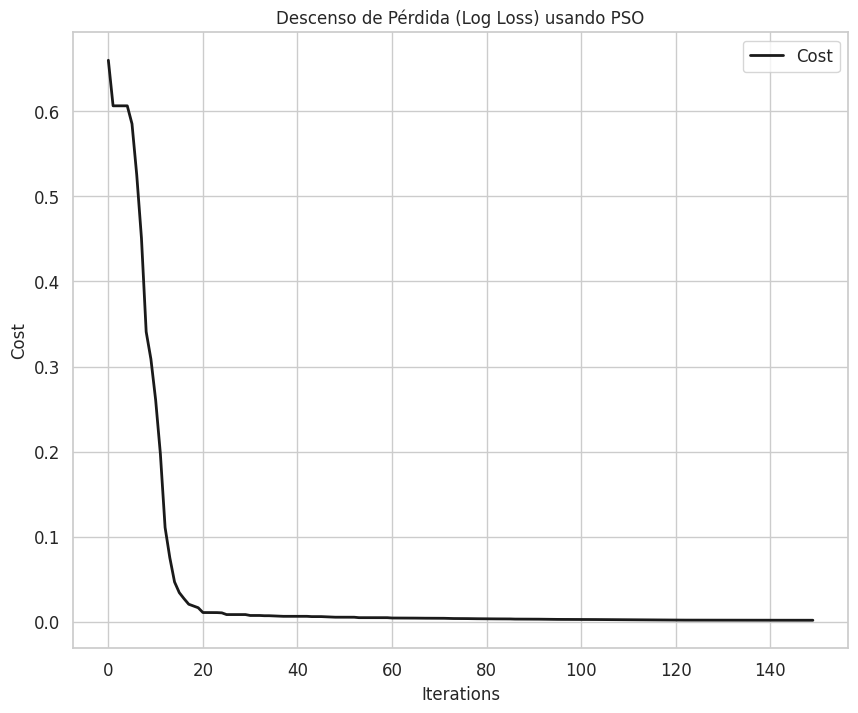

In [29]:
options_nn = {'c1': 0.6, 'c2': 0.4, 'w': 0.9}
optimizer_nn = ps.single.GlobalBestPSO(n_particles=100, dimensions=dim_total, options=options_nn)

print("Entrenando Red Neuronal (42 parámetros) con PSO...")
cost_nn, pos_nn = optimizer_nn.optimize(evaluate_nn_pso, iters=150)

final_preds = forward_pass(pos_nn, X_c)
final_acc = accuracy_score(y_c, np.argmax(final_preds, axis=1))
print(f"\nPrecisión final: {final_acc*100:.2f}%")

plot_cost_history(cost_history=optimizer_nn.cost_history)
plt.title('Descenso de Pérdida (Log Loss) usando PSO')
plt.show()

## Reto D: Agrupamiento (Clustering) con PSO (Reto Alternativo)
**Objetivo:** Usar PSO para encontrar los centroides óptimos de agrupamiento en un espacio de alta dimensión, previniendo el problema de los mínimos locales del algoritmo K-Means.
**Dataset:** Digits MNIST (1,797 imágenes de 64 pixeles cada una).

**El Ciclo del Algoritmo:**
1. **Representación:** Una partícula almacena las coordenadas de $K$ centroides en el espacio dimensional de los datos. Para 10 dígitos y 64 variables, la dimensión de la partícula es 640.
2. **Inicialización:** Posiciones aleatorias dentro de los límites de los datos (valores de pixeles).
3. **Aptitud (Fitness):** Minimizar el Error Cuadrático de Cuantización (la suma de las distancias cuadradas euclidianas entre cada imagen y su centroide más cercano).
4. **Comportamiento y Evolución:** El enjambre mueve los conjuntos de centroides hasta estabilizarlos en las agrupaciones óptimas globales.

In [30]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist

data_digits = load_digits()
X_d = data_digits.data / 16.0

k_clusters = 10
n_dims = X_d.shape[1]
dim_pso = k_clusters * n_dims

def evaluate_clustering_pso(swarm):
    losses = np.zeros(swarm.shape[0])
    for i in range(swarm.shape[0]):
        centroids = swarm[i].reshape((k_clusters, n_dims))
        distances = cdist(X_d, centroids, 'euclidean')
        min_distances = np.min(distances, axis=1)
        losses[i] = np.sum(min_distances**2)
    return losses

2026-05-02 03:09:38,827 - pyswarms.single.global_best - INFO - Optimize for 100 iters with {'c1': 1.0, 'c2': 1.0, 'w': 0.7}


Agrupando dígitos en 64 dimensiones...


pyswarms.single.global_best: 100%|██████████|100/100, best_cost=1.41e+4
2026-05-02 03:09:42,464 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 14106.940841486361, best pos: [0.50800588 0.48692431 0.624018   0.51148591 0.58519775 0.52798404
 0.38674026 0.27426718 0.29869422 0.31519658 0.6263371  0.36387447
 0.80571863 0.42589826 0.37892034 0.80114186 0.57355004 0.37597544
 0.17855743 0.59438593 0.52045408 0.6016771  0.38194342 0.50550152
 0.63188854 0.79014952 0.51788191 0.44200037 0.39719356 0.74369267
 0.41098653 0.48443188 0.29784453 0.26900774 0.33719438 0.50426404
 0.78806975 0.46105487 0.79950483 0.24687146 0.45729623 0.88771325
 0.38824185 0.34370983 0.30748966 0.62886667 0.43369784 0.52329634
 0.66953654 0.52218274 0.84880124 0.50373325 0.38403958 0.39658433
 0.51677468 0.59481927 0.54741466 0.38739225 0.54516246 0.42505129
 0.71711865 0.4370522  0.41491516 0.50671129 0.14585993 0.22279684
 0.18085009 0.63849868 0.54322902 0.65608608 0.44287123 0.42567

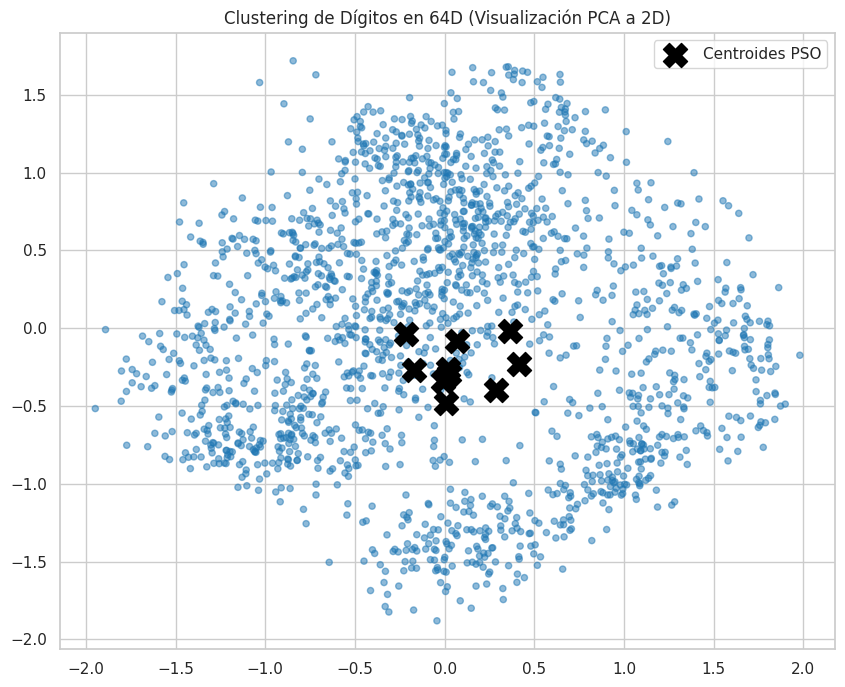

In [31]:
bounds_cl = (np.zeros(dim_pso), np.ones(dim_pso))
options_cl = {'c1': 1.0, 'c2': 1.0, 'w': 0.7}
optimizer_cl = ps.single.GlobalBestPSO(n_particles=30, dimensions=dim_pso, options=options_cl, bounds=bounds_cl)

print("Agrupando dígitos en 64 dimensiones...")
cost_cl, pos_cl = optimizer_cl.optimize(evaluate_clustering_pso, iters=100)

final_centroids = pos_cl.reshape((k_clusters, n_dims))
labels = np.argmin(cdist(X_d, final_centroids, 'euclidean'), axis=1)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_d)
cent_pca = pca.transform(final_centroids)

plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', alpha=0.5, s=20)
plt.scatter(cent_pca[:, 0], cent_pca[:, 1], c='black', marker='X', s=300, label='Centroides PSO')
plt.title('Clustering de Dígitos en 64D (Visualización PCA a 2D)')
plt.legend()
plt.show()